In [1]:
import sys
sys.path.append("../../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
from synthetic_observations import Observations
from gaussian_synthetic_observations import Gaussian_Observations
from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA
# from mala import MALAnew
import h5py

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
change_res=True
snr = 10
N = 100

In [4]:
filepath = "../results/testingB_output_i6_snr10_nspec10.h5"


with h5py.File(filepath, "r") as f:
    spectrum_group = f['Order']['Observational Parameters']['Spectrum']
    spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}

# Now seed0_group is fully loaded into memory
print(spectrum_analysis.keys())
posterior_spectrum = torch.tensor(spectrum_analysis['posterior_spectrum_samples'][:,:,:],dtype=torch.float64,device=device)[0]
template = torch.tensor(spectrum_analysis['template'],dtype=torch.float64,device=device)

dict_keys(['posterior_spectrum_samples', 'template', 'true_spectrum'])


# Create Observations

In [5]:
obs = Observations(i=6,SNR=snr,filepath='../../data/SPIRou20_val.df',N=N,seed=0,wfile='../../data/SPIRou_wavelength_solution.fits')
synthetic_spectra, uncertainty = obs.make_observations(func='connors',add_RV=True,change_res=change_res,filepath='../../data/SPIRou_wavelength_solution.fits')
synthetic_spectra, uncertainty = obs.post_process()
non_ones = torch.where(obs.padded_wgrid!=1)

# Template

In [19]:
# temp = Template(synthetic_spectra[:,:10],obs.berv[:10],obs.inst_wgrid,obs.wgrid)
# template = temp.make_template(func='scipy')
sbart = RV_Retrieval(snr,template,obs.wgrid,obs.inst_wgrid,10)
templatervs, tempuncs = sbart.find_dv(synthetic_spectra[:,:].cpu(),uncertainty.cpu()[:,:],obs.berv[:].cpu(),func='connors')

# Intrinsinc RV

In [29]:
sbart = RV_Retrieval(snr,obs.training[:,:,non_ones[0][0]:non_ones[0][-1]+1],obs.wgrid,obs.inst_wgrid,0,type='sample')
intrvs, uncs = sbart.find_dv(synthetic_spectra[:,:].cpu(),uncertainty.cpu()[:,:],obs.berv[:].cpu(),func='connors')

In [30]:
posterior_spectrum.mean(dim=(0),keepdim=True)[:,:,non_ones[0][0]:non_ones[0][-1]+1].shape

torch.Size([1, 1, 18681])

In [31]:
sbart = RV_Retrieval(snr,posterior_spectrum.mean(dim=(0),keepdim=True)[:,:,non_ones[0][0]:non_ones[0][-1]+1],obs.wgrid,obs.inst_wgrid,0,type='sample')
priorrvs, prioruncs = sbart.find_dv(synthetic_spectra[:,:].cpu(),uncertainty.cpu()[:,:],obs.berv[:].cpu(),func='connors')

# Gibbs MALA

In [68]:
%reload_ext autoreload

In [69]:
mala = MALA(synthetic_spectra[:,:],uncertainty[:,:],obs.berv[:],snr,obs.inst_wgrid,obs.wgrid)
init_rvs = torch.tensor(templatervs).to(DEVICE).unsqueeze(0).expand(1,100)
samples_int, accepted_int = mala.find_rv(init_rvs,posterior_spectrum[0,:,non_ones[0][0]:non_ones[0][-1]+1],1000)

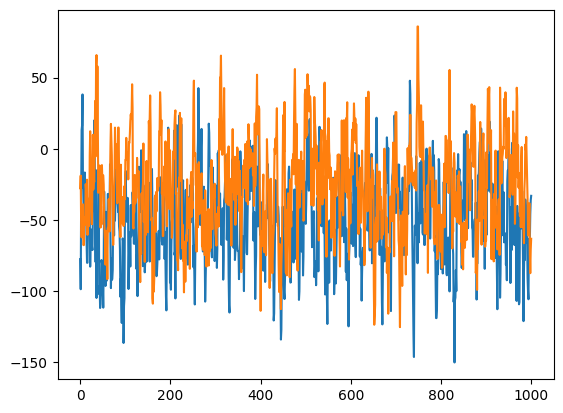

In [70]:
plt.plot(samples_int[:,0,0].cpu())
plt.plot(samples_int[:,0,4].cpu())
# plt.plot(samples_int[:,0,10].cpu())

In [71]:
torch.sum(accepted_int[100:,0,0])/len(accepted_int[100:,0,0])

tensor(0.9545, device='cuda:0')

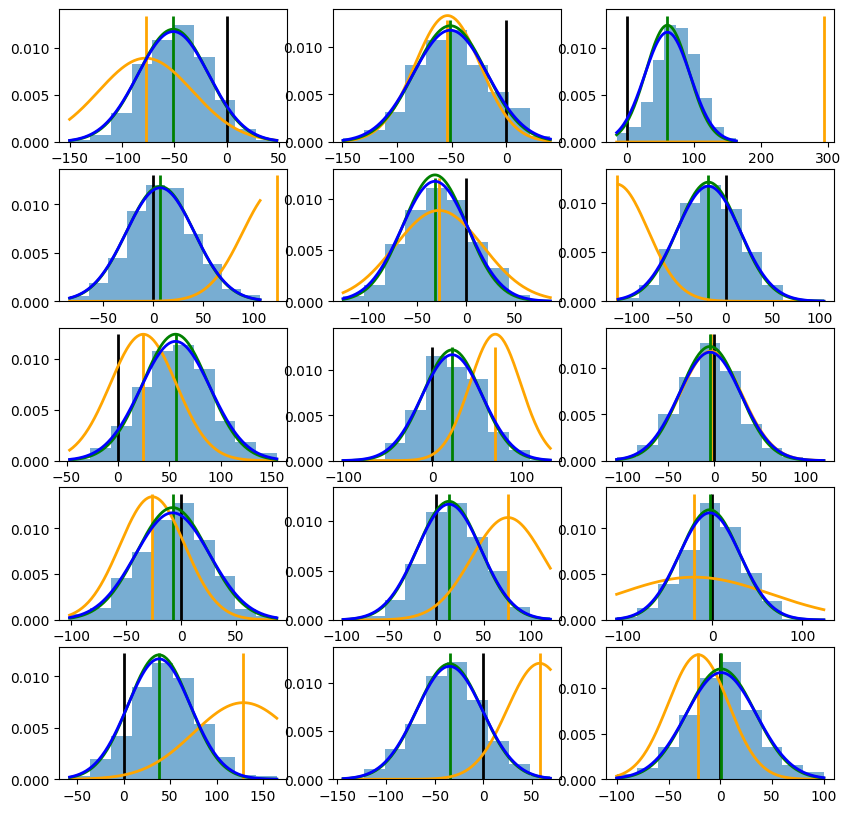

In [72]:
from scipy.stats import norm

fix, axs = plt.subplots(5,3,figsize=(10,10))
axs = axs.flatten()  # Flatten to easily index from 0 to 8

for i in range(15):
    n, bins,_ = axs[i].hist(samples_int[100:,:,i].cpu().flatten(),density=True,alpha=0.6)
    axs[i].vlines(obs.planet[i].cpu(),0,max(n)+0.001,color="k",lw=2)
    axs[i].vlines(templatervs[i],0,max(n)+0.001,color="orange",lw=2)
    axs[i].vlines(intrvs[i],0,max(n)+0.001,color="green",lw=2)

    # Gaussian curve
    x = np.linspace(bins[0], bins[-1], 200)  # smooth x-axis
    y = norm.pdf(x,templatervs[i], tempuncs[i])  # PDF values
    axs[i].plot(x, y, 'orange', linewidth=2)

    y = norm.pdf(x,intrvs[i], uncs[i])  # PDF values
    axs[i].plot(x, y, 'green', linewidth=2)

    y = norm.pdf(x,intrvs[i], mala.deltaV.cpu())  # PDF values
    axs[i].plot(x, y, 'blue', linewidth=2)
    

In [73]:
temp_res = torch.sqrt(torch.mean((obs.planet.cpu()[:] - templatervs)**2))
tempmeanzscore = torch.mean((obs.planet.cpu()[:] - templatervs)/torch.tensor(tempuncs))
tempstdzscore = torch.std((obs.planet.cpu()[:] - templatervs)/torch.tensor(tempuncs))
print(temp_res, tempmeanzscore,tempstdzscore)

tensor(69.2650) tensor(-0.0284) tensor(1.9810)


In [74]:
int_res = torch.sqrt(torch.mean((obs.planet.cpu()[:] - intrvs)**2))
intmeanzscore = torch.mean((obs.planet.cpu()[:] - intrvs)/torch.tensor(uncs))
intstdzscore = torch.std((obs.planet.cpu()[:] - intrvs)/torch.tensor(uncs))
print(int_res, intmeanzscore,intstdzscore)

tensor(36.4526) tensor(0.0692) tensor(1.1145)


In [75]:
prior_res = torch.sqrt(torch.mean((obs.planet.cpu()[:] - priorrvs)**2))
priormeanzscore = torch.mean((obs.planet.cpu()[:] - priorrvs)/torch.tensor(prioruncs))
priorstdzscore = torch.std((obs.planet.cpu()[:] - priorrvs)/torch.tensor(prioruncs))
print(prior_res, priormeanzscore,priorstdzscore)

tensor(36.5365) tensor(0.0520) tensor(1.1166)


In [76]:
gibsrv = torch.mean(samples_int[100:],axis=0)[0].cpu()
gibsuncs = torch.std(samples_int[100:],axis=0)[0].cpu()

gib_res = torch.sqrt(torch.mean((obs.planet.cpu()[:] - gibsrv)**2))
gibmeanzscore = torch.mean((obs.planet.cpu()[:] - gibsrv)/torch.tensor(gibsuncs))
gibstdzscore = torch.std((obs.planet.cpu()[:] - gibsrv)/torch.tensor(gibsuncs))
print(gib_res, gibmeanzscore,gibstdzscore)

tensor(36.4980) tensor(-0.0753) tensor(1.1197)


/tmp/ipykernel_826545/570987661.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gibmeanzscore = torch.mean((obs.planet.cpu()[:] - gibsrv)/torch.tensor(gibsuncs))
/tmp/ipykernel_826545/570987661.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gibstdzscore = torch.std((obs.planet.cpu()[:] - gibsrv)/torch.tensor(gibsuncs))


In [77]:
torch.mean(torch.std(samples_int[100:],axis=0)[0]), np.mean(prioruncs), np.mean(uncs)

(tensor(32.8223, device='cuda:0'), 32.82755902608855, 32.75836966953091)

In [ ]:
obs.planet.cpu() - gibsrv

In [ ]:
obs.planet.cpu() - intrvs

In [ ]:
plt.plot(obs.inst_wgrid.cpu(),synthetic_spectra[0,0].cpu())
plt.plot(obs.wgrid.cpu(),template.cpu())
plt.ylim(5000,11000)

In [ ]:
## Retrieve spectrum
import pickle
filepath = "../../data/SPIRou20_val.df"
with open(filepath, 'rb') as f:
    data = pickle.load(f)

df_reset = data.reset_index(drop=True)
df_reset.index[(df_reset['teff']==3000)&(df_reset['logg']==5.5)&(df_reset['metal']==-0.5)]


In [ ]:
data.iloc[386]